### Astrostatistics lecture 15

In [27]:
import urllib.request
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from tqdm import tqdm
from scipy import stats
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.cluster import MeanShift
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")
df_stars = pd.read_csv("stars.csv")

In [28]:
df_stars        #our data set

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


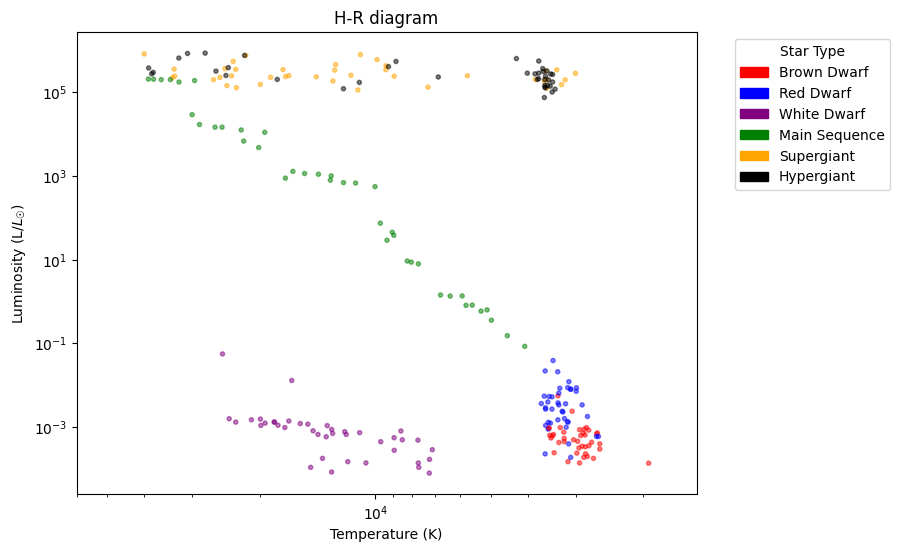

In [29]:
temperature = df_stars["Temperature (K)"].values
luminosity = df_stars["Luminosity(L/Lo)"].values
radius = df_stars["Radius(R/Ro)"].values
absolute_magnitude = df_stars["Absolute magnitude(Mv)"].values
classification = df_stars["Star type"].values

# Mappa colori
color_map = {
    'Brown Dwarf': 'red',
    'Red Dwarf': 'blue',
    'White Dwarf': 'purple',
    'Main Sequence': 'green',
    'Supergiant': 'orange',
    'Hypergiant': 'black'
}


legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in color_map.items()
]

# Applico mapping
colors = [color_map[c] for c in classification]

# Plot H-R diagram
plt.figure(figsize=(8,6))
plt.scatter(temperature, luminosity, c=colors, alpha=0.5, marker='.')

plt.title('H-R diagram')
plt.xscale('log')
plt.yscale('log')
plt.xlim(max(temperature)*1.5, min(temperature)*0.75)
plt.legend(handles=legend_handles, title="Star Type",
           bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Temperature (K)")
plt.ylabel("Luminosity (L/$L_☉$)")

plt.show()

The explained variance is: 0.9999942118846565


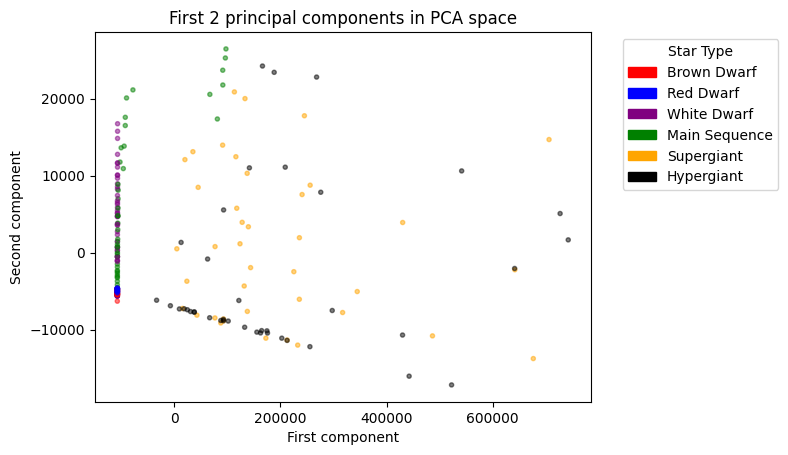

In [30]:
#if we don't rescale the data 
data = np.array([temperature, luminosity, radius, absolute_magnitude]).T #.T used to have the correct (n_values, n_features) shape 

pca = PCA(n_components=2) # 2 components
data_pca = pca.fit_transform(data)

evals = pca.explained_variance_ratio_ 
print(f"The explained variance is: {np.sum(evals)}")

plt.scatter(data_pca[:, 0], data_pca[:, 1], c=colors, alpha=0.5, marker='.')
plt.legend(handles=legend_handles, title="Star Type",
           bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("First component")
plt.ylabel("Second component")
plt.title("First 2 principal components in PCA space")
plt.show()

The explained variance is: 0.8385817508043482


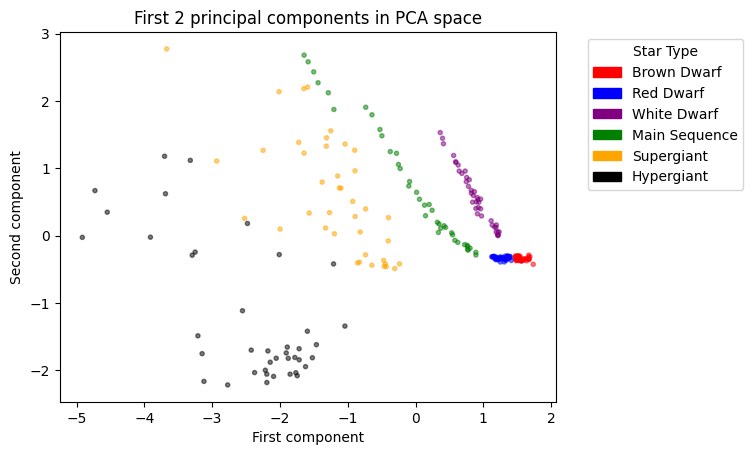

In [31]:
#Now we first standardize the data
data_raw = np.array([temperature, luminosity, radius, absolute_magnitude]).T
scaler = StandardScaler()
data = scaler.fit_transform(data_raw)

pca = PCA(n_components=2) # 2 components

#now project back into PCA space
data_pca = pca.fit_transform(data)

evals = pca.explained_variance_ratio_ 
print(f"The explained variance is: {np.sum(evals)}")



plt.scatter(data_pca[:, 0], data_pca[:, 1], c=colors, alpha=0.5, marker='.')
plt.xlabel("First component")
plt.ylabel("Second component")
plt.title("First 2 principal components in PCA space")
plt.legend(handles=legend_handles, title="Star Type",
           bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


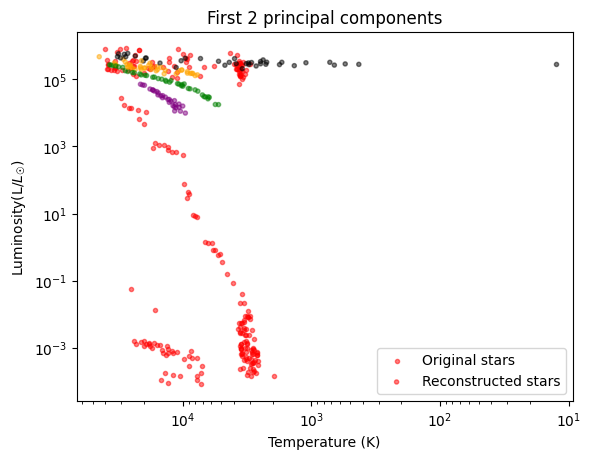

In [34]:
#back into the original space we should get the original data (sort of)
data_back = pca.inverse_transform(data_pca)
data_rec = scaler.inverse_transform(data_back)

plt.scatter(data_raw[:, 0], data_raw[:, 1], label="Original stars", alpha=0.5, color='red', marker='.')
plt.scatter(data_rec[:, 0], data_rec[:, 1], label='Reconstructed stars', c=colors, alpha=0.5, marker='.')
plt.xlabel("Temperature (K)")
plt.ylabel(f"Luminosity(L/$L_☉$)")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlim(max(data_rec[:, 0])*1.5, min(data_rec[:, 0])*0.75)
plt.title("First 2 principal components")
plt.show()